In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action='ignore',category=np.VisibleDeprecationWarning)

## Prediction ##

In [4]:
families = Table.read_table('family_heights.csv')
families

family,father,mother,child,children,order,sex
1,78.5,67,73.2,4,1,male
1,78.5,67,69.2,4,2,female
1,78.5,67,69,4,3,female
1,78.5,67,69,4,4,female
2,75.5,66.5,73.5,4,1,male
2,75.5,66.5,72.5,4,2,male
2,75.5,66.5,65.5,4,3,female
2,75.5,66.5,65.5,4,4,female
3,75,64,71,2,1,male
3,75,64,68,2,2,female


In [5]:
parent_avgs = (families.column('father') + families.column('mother'))/2

In [6]:
heights = Table().with_columns(
    'Parent Average', parent_avgs,
    'Child', families.column('child'),
    'Sex', families.column('sex')
)
heights

Parent Average,Child,Sex
72.75,73.2,male
72.75,69.2,female
72.75,69,female
72.75,69,female
71,73.5,male
71,72.5,male
71,65.5,female
71,65.5,female
69.5,71,male
69.5,68,female


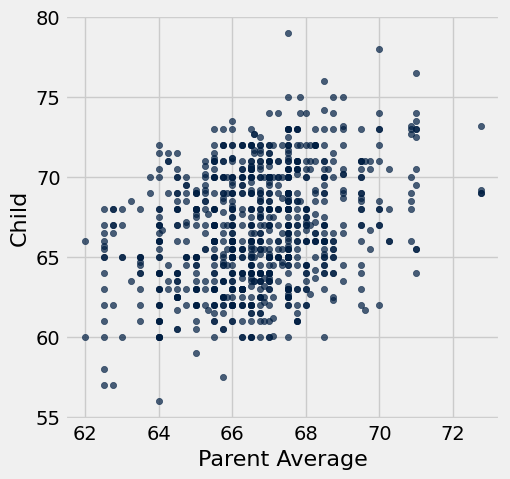

In [7]:
heights.scatter('Parent Average', 'Child')

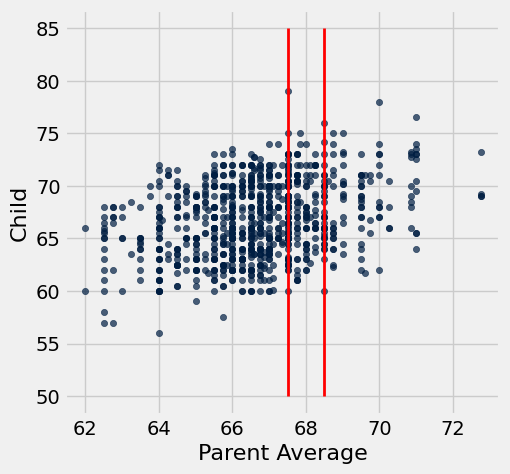

In [8]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2);

In [9]:
nearby = heights.where('Parent Average', are.between(67.5, 68.5))
nearby_mean = np.average(nearby.column('Child'))
nearby_mean

67.620000000000005

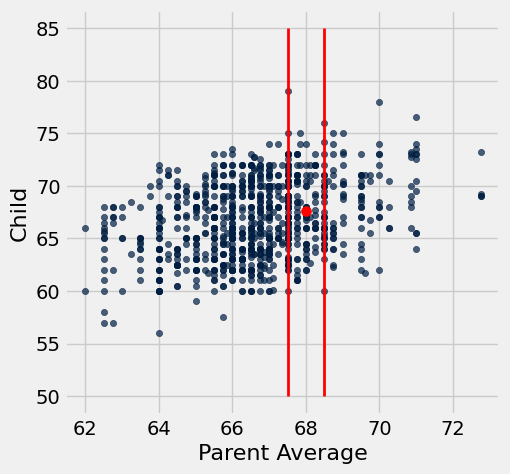

In [10]:
heights.scatter('Parent Average', 'Child')
plots.plot([67.5, 67.5], [50, 85], color='red', lw=2)
plots.plot([68.5, 68.5], [50, 85], color='red', lw=2)
plots.scatter(68, nearby_mean, color='red', s=50);

In [11]:
def predict(h):
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    return np.average(nearby.column('Child'))

In [12]:
predict(68)

67.620000000000005

In [13]:
predict(70)

68.561904761904756

In [14]:
predict(73)

70.099999999999994

In [16]:
predicted_heights = heights.apply(predict, 'Parent Average')
predicted_heights

array([ 70.1       ,  70.1       ,  70.1       ,  70.1       ,
        70.41578947,  70.41578947,  70.41578947,  70.41578947,
        68.5025    ,  68.5025    ,  68.5025    ,  68.5025    ,
        68.5025    ,  68.5025    ,  68.5025    ,  66.48230453,
        66.48230453,  66.48230453,  66.48230453,  66.48230453,
        66.48230453,  70.41578947,  70.41578947,  70.41578947,
        70.41578947,  70.41578947,  70.41578947,  70.41578947,
        69.285     ,  69.285     ,  69.285     ,  69.285     ,
        68.66052632,  67.62      ,  67.62      ,  67.62      ,
        67.62      ,  67.62      ,  67.62      ,  67.62      ,
        67.62      ,  67.46184211,  68.56190476,  68.56190476,
        68.56190476,  68.56190476,  68.66052632,  68.66052632,
        68.66052632,  67.9880597 ,  67.9880597 ,  67.9880597 ,
        67.9880597 ,  67.9880597 ,  67.9880597 ,  67.9880597 ,
        67.9880597 ,  67.9880597 ,  68.05465116,  68.05465116,
        68.05465116,  68.05465116,  68.05465116,  68.05

In [17]:
heights = heights.with_column('Prediction', predicted_heights)
heights

Parent Average,Child,Sex,Prediction
72.75,73.2,male,70.1
72.75,69.2,female,70.1
72.75,69,female,70.1
72.75,69,female,70.1
71,73.5,male,70.4158
71,72.5,male,70.4158
71,65.5,female,70.4158
71,65.5,female,70.4158
69.5,71,male,68.5025
69.5,68,female,68.5025


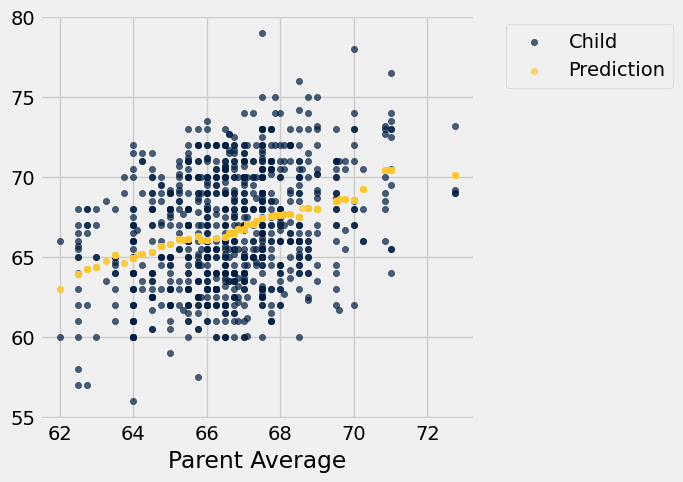

In [18]:
heights.select('Parent Average', 'Child', 'Prediction').scatter('Parent Average')

## Prediction Accuracy ##

In [19]:
def difference(x, y):
    return x - y

In [20]:
pred_errs = heights.apply(difference, 'Prediction', 'Child')
heights = heights.with_column('errors',pred_errs)
heights

Parent Average,Child,Sex,Prediction,errors
72.75,73.2,male,70.1,-3.1
72.75,69.2,female,70.1,0.9
72.75,69,female,70.1,1.1
72.75,69,female,70.1,1.1
71,73.5,male,70.4158,-3.08421
71,72.5,male,70.4158,-2.08421
71,65.5,female,70.4158,4.91579
71,65.5,female,70.4158,4.91579
69.5,71,male,68.5025,-2.4975
69.5,68,female,68.5025,0.5025


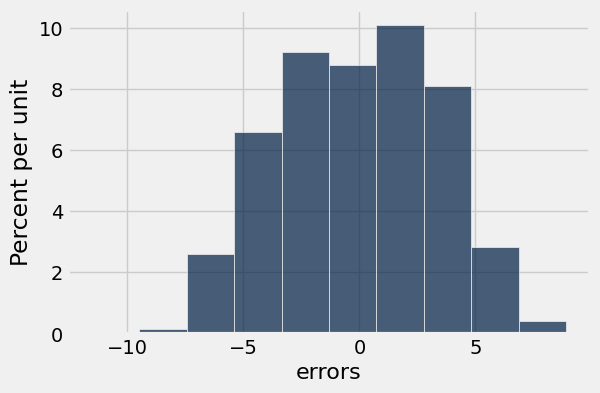

In [21]:
heights.hist('errors')

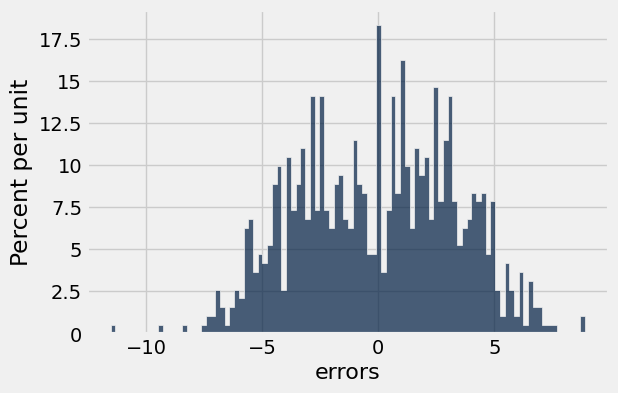

In [23]:
heights.hist('errors', bins=100)

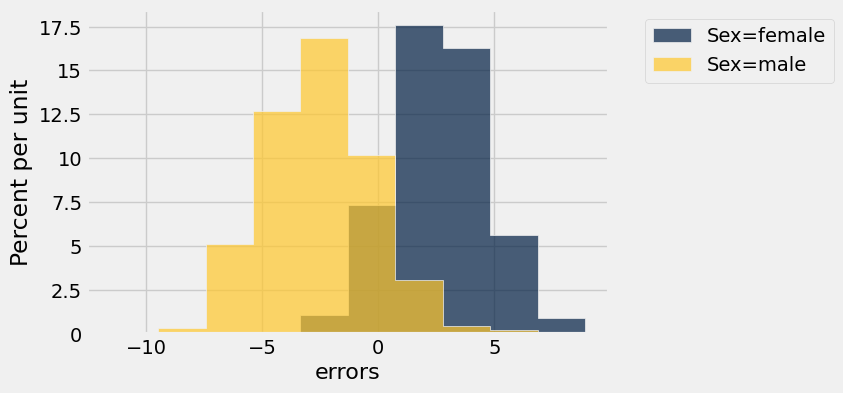

In [24]:
heights.hist('errors', group='Sex')

# Improving the model

In [25]:
def predict_smarter(h, s):
    nearby = heights.where('Parent Average', are.between(h - 1/2, h + 1/2))
    nearby_same_sex = nearby.where('Sex', s)
    return np.average(nearby_same_sex.column('Child'))

In [26]:
predict_smarter(68, 'female')

64.983516483516482

In [27]:
predict_smarter(68, 'male')

70.172340425531914

In [28]:
smarter_predicted_heights = heights.apply(predict_smarter, 'Parent Average', 'Sex')
heights = heights.with_column('Smarter Prediction', smarter_predicted_heights)

In [31]:
smarter_pred_errs = heights.apply(difference, 'Child', 'Smarter Prediction')
heights = heights.with_column('Smarter Errors', smarter_pred_errs)
heights

Parent Average,Child,Sex,Prediction,errors,Smarter Prediction,Smarter Errors
72.75,73.2,male,70.1,-3.1,73.2,0
72.75,69.2,female,70.1,0.9,69.0667,0.133333
72.75,69,female,70.1,1.1,69.0667,-0.0666667
72.75,69,female,70.1,1.1,69.0667,-0.0666667
71,73.5,male,70.4158,-3.08421,73.4889,0.0111111
71,72.5,male,70.4158,-2.08421,73.4889,-0.988889
71,65.5,female,70.4158,4.91579,67.65,-2.15
71,65.5,female,70.4158,4.91579,67.65,-2.15
69.5,71,male,68.5025,-2.4975,70.7955,0.204545
69.5,68,female,68.5025,0.5025,65.7,2.3


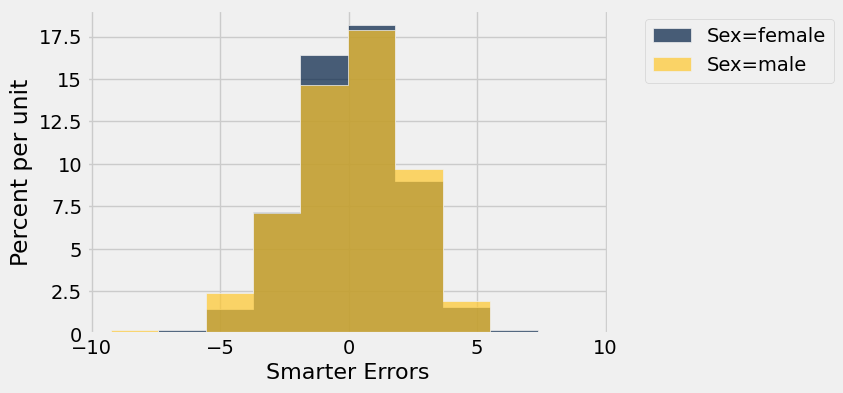

In [30]:
heights.hist('Smarter Errors', group='Sex')

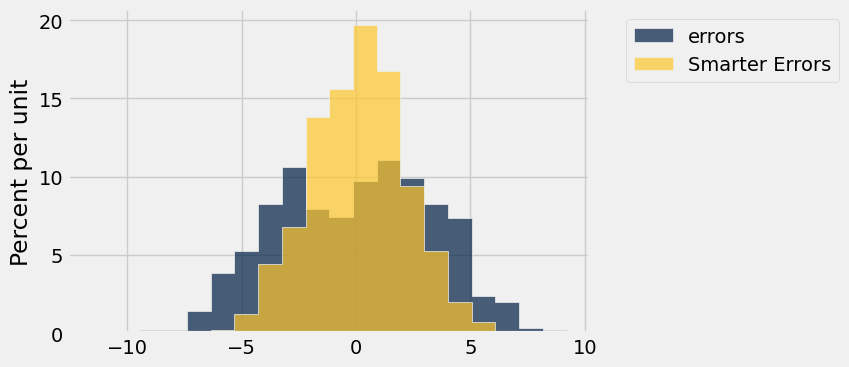

In [32]:
heights.hist('errors', 'Smarter Errors', bins=20)